# Species-class post-processing

Two analyses on a mechanism that carries a `<SpeciesClasses>` block in `kinetics.xml`
(species partitioned into classes such as `C1`, `AROMATICS`, `SOOT-*`):

1. **class-wise elemental distribution** — how an element (here carbon) is spread across
   the classes along the run;
2. **flux by class** — the directed class → class element-flux matrix, plus a pruned graph.

Fixture: a constant-T batch reactor, C1 → C2 → PAH → soot over 1 s.

In [1]:
import os

import matplotlib.pyplot as plt
from IPython.display import display

from pySMOKEPostProcessor import PostProcessor, plot_class_distribution, plot_heatmap

kineticFolder = os.path.join("..", "data", "SpeciesClasses", "kinetics")
resultsFolder = os.path.join("..", "data", "SpeciesClasses", "Output")

pp = PostProcessor(kineticFolder, resultsFolder)

## 1. Class-wise elemental distribution

`ElementalDistributionByClass(element, normalize)` returns a DataFrame indexed by the
independent variable (time here), one column per class. With `normalize=True` every row
sums to 1, so the stacked-area plot fills to 100 %.

In [2]:
carbon = pp.ElementalDistributionByClass(element="C", normalize=True)
carbon.iloc[[0, len(carbon) // 2, -1]]

,COLLIDERS,C1,C2,C3,C4,C5,LONG-ALKANES,AROMATICS,HEAVY-PAHs,SOOT-LIQUID-LIKE-PARTICLES,SOOT-PRIMARY-PARTICLES,SOOT-AGGREGATES-I,SOOT-AGGREGATES-II,SOOT-AGGREGATES-III
0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.139007,0.0,0.785892,0.081969,0.010543,0.003811,1.306573e-06,8.165179e-06,0.094922,0.001209,0.000155,0.000113,0.008742,0.010890,0.001744
1.000000,0.0,0.330244,0.067397,0.001707,0.000669,3.510527e-07,8.065084e-07,0.041538,0.000473,0.000044,0.000041,0.253918,0.303319,0.000649


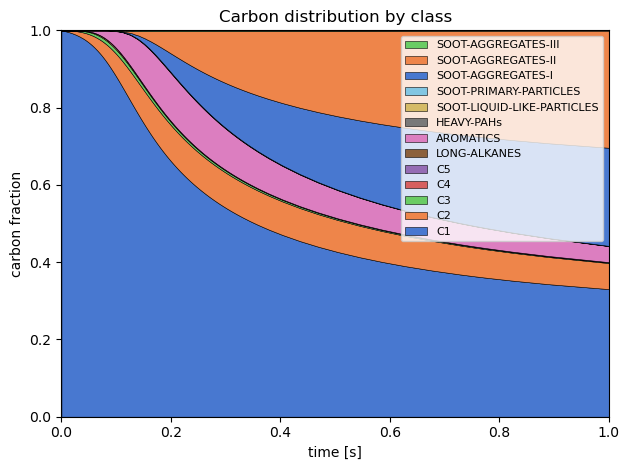

In [3]:
fig, ax = plot_class_distribution(
    carbon, xlabel="time [s]", ylabel="carbon fraction", title="Carbon distribution by class"
)

Unnormalised, the per-class total is moles of the element per kg of mixture; for a closed
gas-phase run the sum over classes is conserved.

In [4]:
carbon_abs = pp.ElementalDistributionByClass(element="C", normalize=False)
print("total C  t=0 :", carbon_abs.iloc[0].sum())
print("total C  t=end:", carbon_abs.iloc[-1].sum())

total C  t=0 : 0.06233248244911986
total C  t=end: 0.0623324815448987


## 2. Flux by class

`FluxAnalysisByClass` always returns the **full directed** class × class element-flux
matrix (`res["matrix"]`, rows = source class, columns = target class). The graph
(`res["graph"]`) is a breadth-first walk of that matrix from a seed, pruned by
`depth` / `width` / `threshold`.

- `flux_per_class=True` (default): seed by `class_name`.
- `flux_per_class=False`: seed by `species_name` (walk starts from that species' class).
- exactly one of `class_name` / `species_name` may be given.

`carbon_weighted=True` (default) is OpenSMOKE's carbon-atom throughput
`n_i·n_j·|R_r| / N_C,r`; for a soot mechanism the soot–soot block dominates because the
weight scales with (bin carbon count)². `carbon_weighted=False` splits each reaction's
own rate `|R_r|` by carbon share, keeping lumped BIN classes comparable to the gas.

In [ ]:
res = pp.FluxAnalysisByClass(
    element="C",
    flux_analysis_type="production",   # where the carbon goes
    class_name="SOOT-LIQUID-LIKE-PARTICLES",
    flux_per_class=True,
    depth=2,
    width=4,
    threshold=1.0,
    local_value=0.1,                    # t = 0.5 s
    carbon_weighted=False,
)
res["matrix"]

,COLLIDERS,C1,C2,C3,C4,C5,LONG-ALKANES,AROMATICS,HEAVY-PAHs,SOOT-LIQUID-LIKE-PARTICLES,SOOT-PRIMARY-PARTICLES,SOOT-AGGREGATES-I,SOOT-AGGREGATES-II,SOOT-AGGREGATES-III
COLLIDERS,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
C1,0.0,2.390995e-02,5.128132e-03,2.423368e-03,8.964633e-04,8.270169e-07,1.559486e-10,1.670968e-03,3.259343e-06,2.918402e-10,6.092921e-09,0.000000e+00,0.000000e+00,0.000000e+00
C2,0.0,6.797361e-04,1.420774e-02,4.303735e-03,3.892457e-05,4.547964e-06,1.188290e-05,3.740926e-04,3.454420e-07,2.455972e-08,4.435311e-10,1.485579e-12,2.770805e-14,5.479476e-15
C3,0.0,3.971605e-04,2.767602e-04,5.927839e-03,2.382590e-03,6.821478e-06,5.554993e-07,1.514296e-03,4.601623e-08,5.086704e-11,1.203229e-12,5.163032e-15,2.724500e-16,2.146350e-16
C4,0.0,1.491753e-04,2.775132e-03,1.492812e-04,1.666668e-03,3.174339e-06,2.379333e-05,1.146934e-04,3.019556e-09,2.534214e-11,5.853707e-13,2.463507e-15,1.289251e-16,1.014364e-16
C5,0.0,5.410445e-07,1.231453e-06,1.848024e-06,1.995538e-06,8.792690e-06,3.783868e-11,1.017997e-05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
LONG-ALKANES,0.0,4.027159e-08,1.684037e-08,1.298768e-07,1.855374e-07,1.259664e-10,7.316358e-09,3.563337e-05,6.246409e-20,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
AROMATICS,0.0,1.523218e-03,1.328945e-04,8.990187e-05,7.377321e-06,1.102912e-07,5.350419e-09,3.478592e-02,3.318854e-05,2.338844e-07,4.207947e-08,2.610437e-10,1.837172e-11,2.699096e-12
HEAVY-PAHs,0.0,2.160515e-06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.225978e-08,2.295332e-04,7.145582e-06,9.665228e-07,1.907990e-11,8.958387e-13,9.614346e-14
SOOT-LIQUID-LIKE-PARTICLES,0.0,5.367159e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.476205e-09,1.279808e-05,7.917683e-07,4.110868e-10,1.173103e-11,1.021694e-11


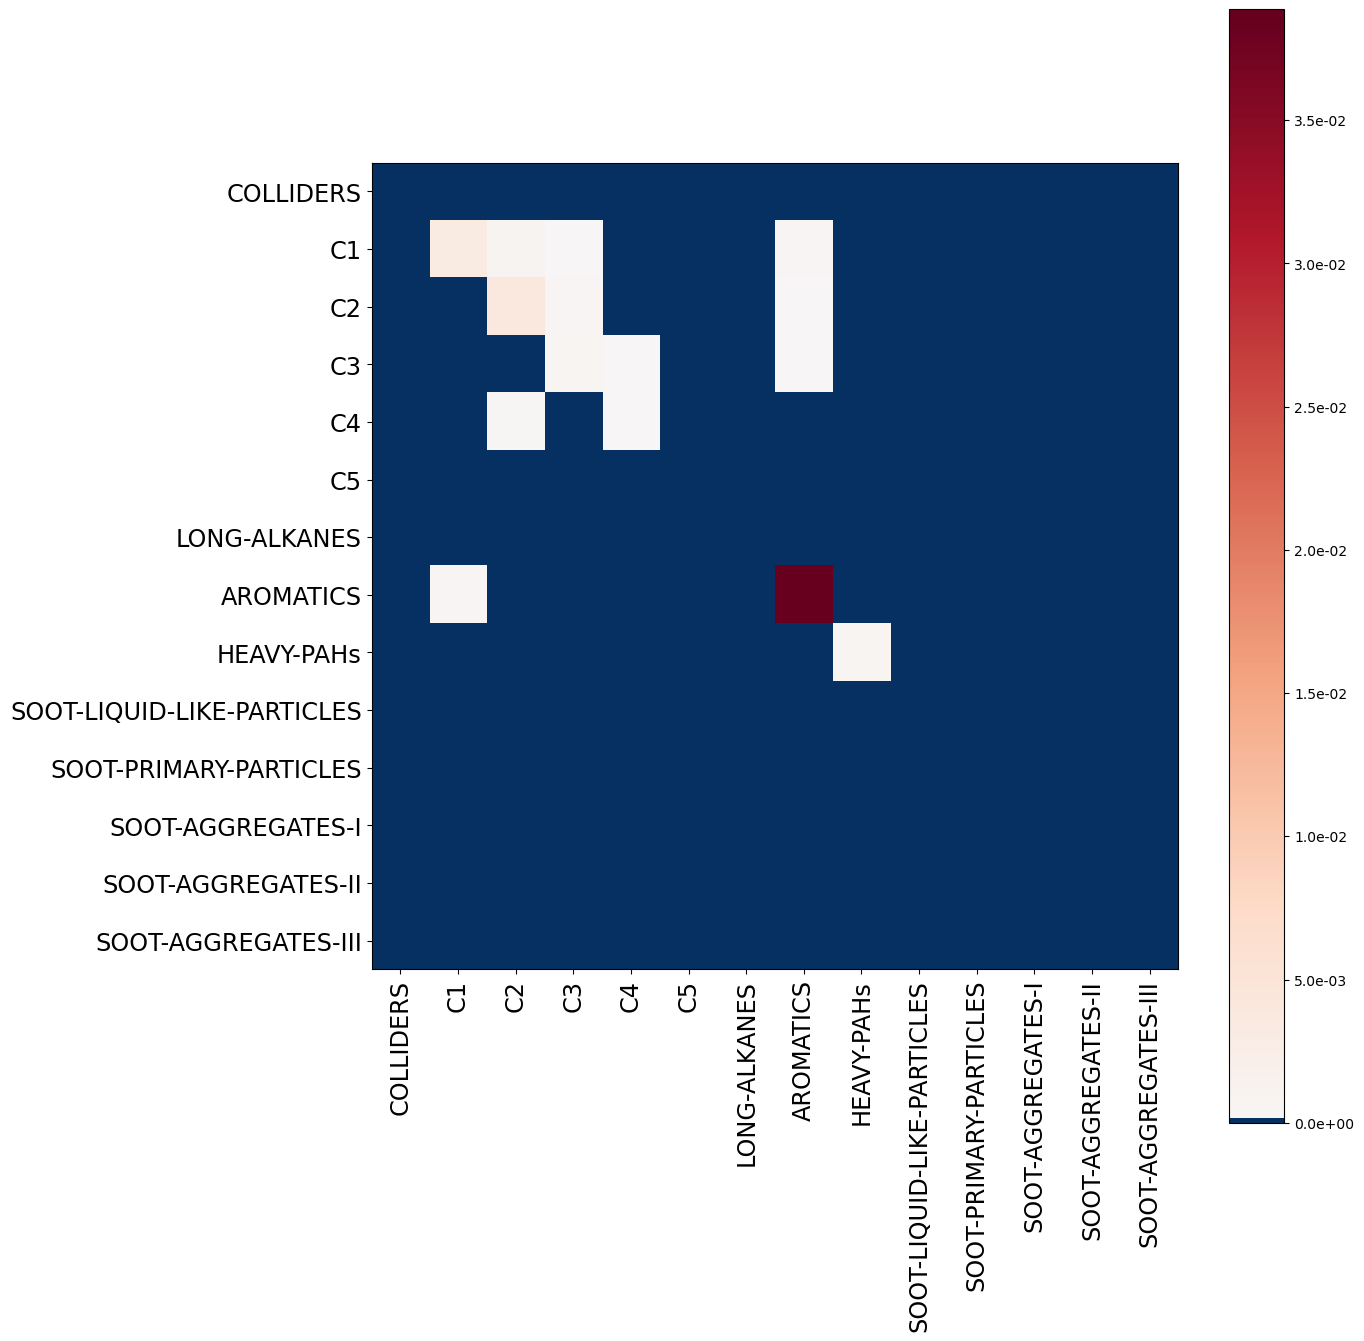

In [8]:
fig = plot_heatmap(res["matrix"], symmetricaxis=False, dftype="generic")

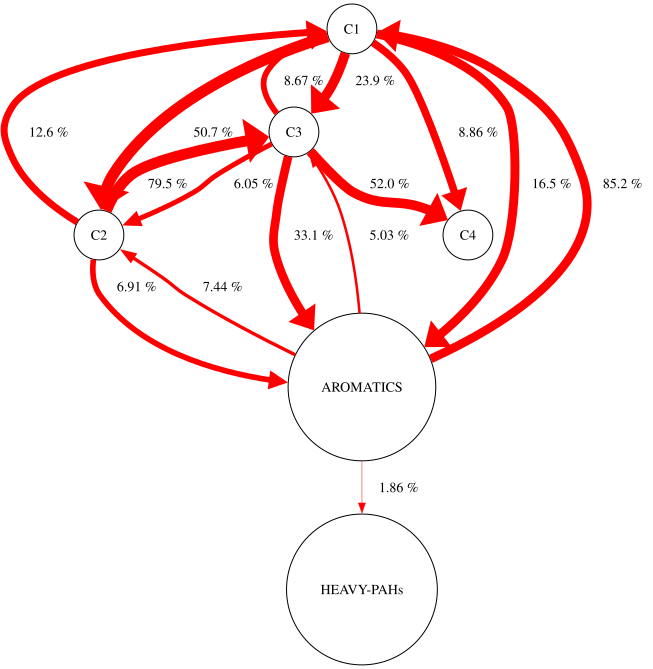

In [16]:
display(res["graph"])

### Same instant, seeded from a species, bounded weighting

`flux_per_class=False` + `species_name`, and `carbon_weighted=False` so the gas network
stays visible next to the soot classes.

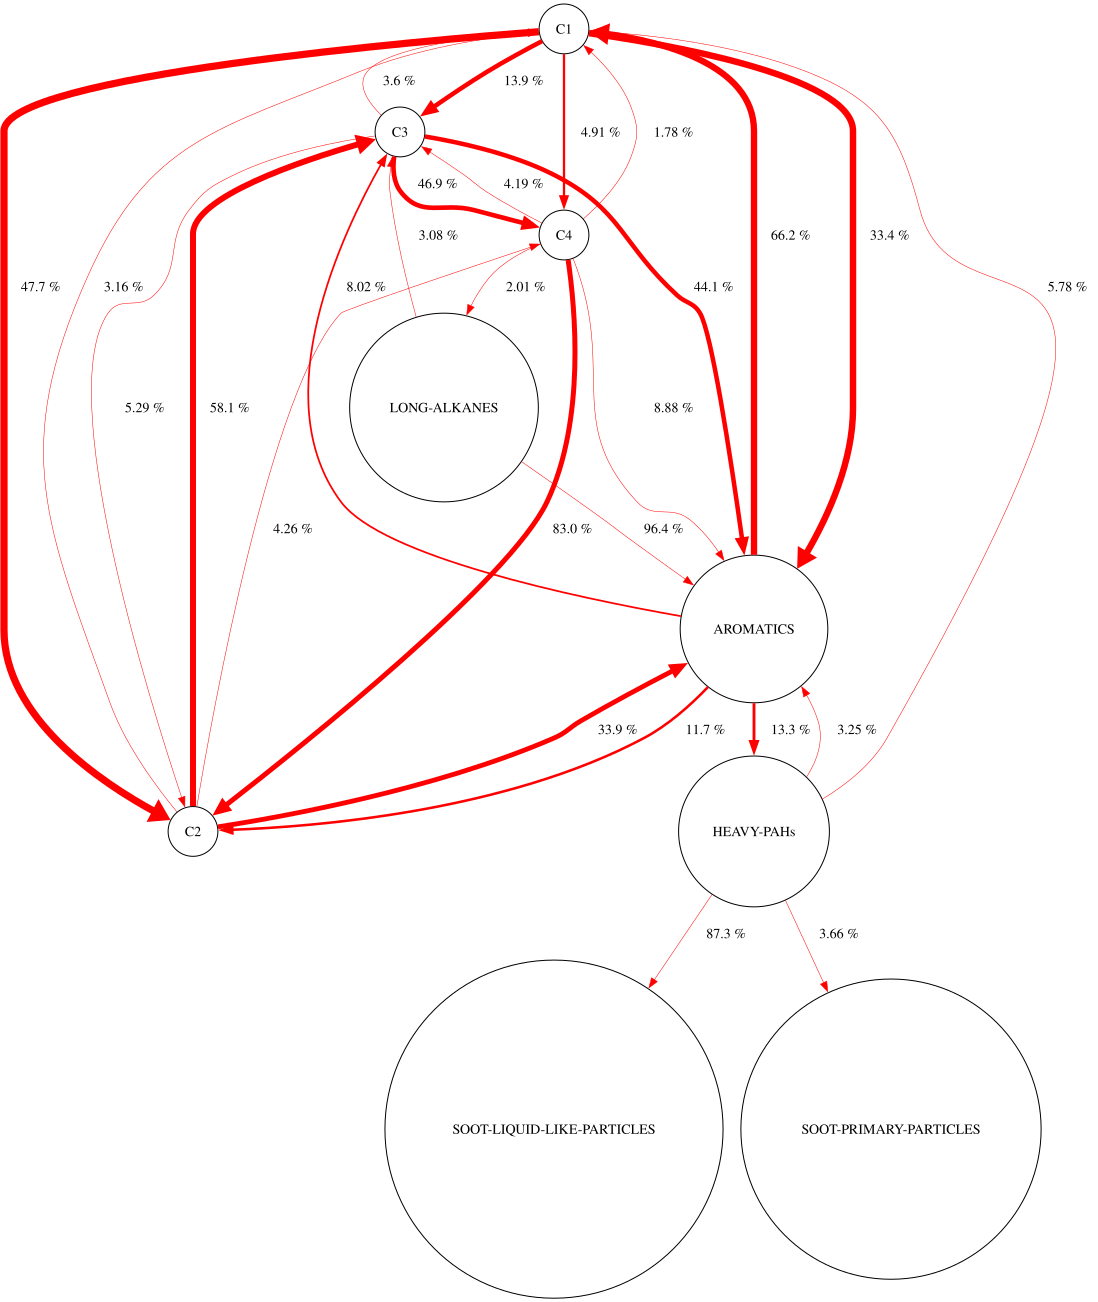

In [10]:
res_sp = pp.FluxAnalysisByClass(
    element="C",
    flux_analysis_type="destruction",
    species_name="C2H2",
    flux_per_class=False,
    depth=3,
    width=5,
    threshold=1.0,
    local_value=0.5,
    carbon_weighted=False,
)
display(res_sp["graph"])

The **matrix is the same** whichever seed you pass (`class_name` or `species_name`)
and whatever `flux_analysis_type` you pick — seed and direction only shape the *graph*.
It does change with `carbon_weighted` (the weighting) and `local_value` (the state).